In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit1025.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit1047.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit486.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit728.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit1013.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit282.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit687.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit889.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit554.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit772.txt
/kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels/circuit305.txt
/kaggle/input/yol

In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninst

In [3]:
from ultralytics import YOLO
import time, pandas as pd, os, zipfile

# dataset path
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# best params (from analysis)
best_params = {
    "Epochs": 32,
    "Batch": 16,
    "lr0": 0.005,
    "Weight Decay": 0.0005,
    "Optimizer": "Adamax",
    "Image Size": 640,
    "Dropout": 0,
    "Freeze Layers": 0,
    "Activation": "SiLU"
}

# results file
results_file = "best_experiment_results.csv"

# initialize CSV if not exists
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Case",
        "Experiment No",
        "Experiment Name",
        "Epochs",
        "Batch",
        "lr0",
        "Weight Decay",
        "Optimizer",
        "Image Size",
        "Dropout",
        "Freeze Layers",
        "Activation",
        "Training Time (s)",
        "Precision",
        "Recall",
        "mAP@0.5",
        "mAP@0.5:0.95"
    ]).to_csv(results_file, index=False)

def log_result(case, exp_no, exp_name, epochs, results, train_time, params):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)

    new_row = {
        "Case": case,
        "Experiment No": exp_no,
        "Experiment Name": exp_name,
        "Epochs": epochs,
        "Batch": int(results.args['batch']),
        "lr0": params["lr0"],
        "Weight Decay": params["Weight Decay"],
        "Optimizer": params["Optimizer"],
        "Image Size": params["Image Size"],
        "Dropout": params["Dropout"],
        "Freeze Layers": params["Freeze Layers"],
        "Activation": params["Activation"],
        "Training Time (s)": round(train_time, 2),
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)

# ---------------------------
# Train with best parameters
# ---------------------------
print("🚀 Training with best parameters...")

# load YOLOv8 nano model
model = YOLO("yolov8n.pt")

start = time.time()

results = model.train(
    data=data_yaml,
    epochs=best_params["Epochs"],
    batch=best_params["Batch"],
    lr0=best_params["lr0"],
    weight_decay=best_params["Weight Decay"],
    optimizer=best_params["Optimizer"].lower(),  # ultralytics expects lowercase
    imgsz=best_params["Image Size"],
    dropout=best_params["Dropout"],
    freeze=best_params["Freeze Layers"]
)

end = time.time()
train_time = end - start

# log results
log_result("Best Case", 1, "best_params_run", best_params["Epochs"], results, train_time, best_params)

print("✅ Training complete. Results logged.")

# ---------------------------
# Zip everything
# ---------------------------
def zip_outputs(zip_name="outputs.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                file_path = os.path.join(root, file)
                # avoid zipping other zips recursively
                if not file.endswith(".zip"):
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 All files zipped into {zip_name}")

zip_outputs()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Training with best parameters...
Ultralytics 8.3.203 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=F

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.988      0.985      0.987      0.683
     DC Voltage Source        103        144      0.989      0.972      0.981      0.757
              Resistor        183        605      0.983       0.99      0.985       0.64
        Current Source        113        150      0.976      0.993      0.992      0.742
              Inductor        117        177      0.993      0.989      0.992      0.643
             Capacitor        115        184      0.993      0.989      0.985      0.604
     AC Voltage Source         65        180      0.994      0.979      0.989      0.714
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/train


AttributeError: 'DetMetrics' object has no attribute 'args'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        names (dict[int, str]): A dictionary of class names.
        box (Metric): An instance of the Metric class for storing detection results.
        speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
        task (str): The task type, set to 'detect'.
        stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes, target classes, and target images.
        nt_per_class: Number of targets per class.
        nt_per_image: Number of targets per image.

    Methods:
        update_stats: Update statistics by appending new values to existing stat collections.
        process: Process predicted results for object detection and update metrics.
        clear_

In [4]:
from ultralytics import YOLO
import time, pandas as pd, os, zipfile

# dataset path
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# best params (from analysis)
best_params = {
    "Epochs": 32,
    "Batch": 16,
    "lr0": 0.005,
    "Weight Decay": 0.0005,
    "Optimizer": "Adamax",
    "Image Size": 640,
    "Dropout": 0,
    "Freeze Layers": 0,
    "Activation": "SiLU"
}

# results file
results_file = "best_experiment_results.csv"

# initialize CSV if not exists
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Case",
        "Experiment No",
        "Experiment Name",
        "Epochs",
        "Batch",
        "lr0",
        "Weight Decay",
        "Optimizer",
        "Image Size",
        "Dropout",
        "Freeze Layers",
        "Activation",
        "Training Time (s)",
        "Precision",
        "Recall",
        "mAP@0.5",
        "mAP@0.5:0.95"
    ]).to_csv(results_file, index=False)


def log_result(case, exp_no, exp_name, epochs, results, train_time, params):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)

    new_row = {
        "Case": case,
        "Experiment No": exp_no,
        "Experiment Name": exp_name,
        "Epochs": epochs,
        "Batch": params["Batch"],   # ✅ fixed: no results.args
        "lr0": params["lr0"],
        "Weight Decay": params["Weight Decay"],
        "Optimizer": params["Optimizer"],
        "Image Size": params["Image Size"],
        "Dropout": params["Dropout"],
        "Freeze Layers": params["Freeze Layers"],
        "Activation": params["Activation"],
        "Training Time (s)": round(train_time, 2),   # ✅ include time
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)


# ---------------------------
# Train with best parameters
# ---------------------------
print("🚀 Training with best parameters...")

# load YOLOv8 nano model
model = YOLO("yolov8n.pt")

start = time.time()

results = model.train(
    data=data_yaml,
    epochs=best_params["Epochs"],
    batch=best_params["Batch"],
    lr0=best_params["lr0"],
    weight_decay=best_params["Weight Decay"],
    optimizer=best_params["Optimizer"].lower(),  # ultralytics expects lowercase
    imgsz=best_params["Image Size"],
    dropout=best_params["Dropout"],
    freeze=best_params["Freeze Layers"]
)

end = time.time()
train_time = end - start

# log results
log_result("Best Case", 1, "best_params_run", best_params["Epochs"], results, train_time, best_params)

print("✅ Training complete. Results logged.")

# ---------------------------
# Zip everything
# ---------------------------
def zip_outputs(zip_name="outputs.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                file_path = os.path.join(root, file)
                # avoid zipping other zips recursively
                if not file.endswith(".zip"):
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 All files zipped into {zip_name}")

zip_outputs()


🚀 Training with best parameters...
Ultralytics 8.3.203 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, op

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.988      0.985      0.987      0.683
     DC Voltage Source        103        144      0.989      0.972      0.981      0.757
              Resistor        183        605      0.983       0.99      0.985       0.64
        Current Source        113        150      0.976      0.993      0.992      0.742
              Inductor        117        177      0.993      0.989      0.992      0.643
             Capacitor        115        184      0.993      0.989      0.985      0.604
     AC Voltage Source         65        180      0.994      0.979      0.989      0.714
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/train2
✅ Training complete. Results logged.
📦 All files zipped into outputs.zip


In [5]:
from ultralytics import YOLO
import time, pandas as pd, os, json, zipfile
from tabulate import tabulate

# dataset path
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# best params (YOLOv8-small, imgsz=640)
best_params = {
    "batch": 64,
    "lr0": 0.001,
    "optimizer": "AdamW",
    "imgsz": 640,
    "weight_decay": 0.001,
    "dropout": 0.0,
    "freeze": 0,
    "activation": "SiLU",
    "epochs": 32
}

# results log file
results_file = "small_best_results.csv"

# initialize CSV if not exists
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Experiment", 
        "Epochs", 
        "Training Time (s)", 
        "Precision", 
        "Recall", 
        "mAP@0.5", 
        "mAP@0.5:0.95", 
        "Parameters"
    ]).to_csv(results_file, index=False)

def log_result(experiment, epochs, results, train_time):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)

    new_row = {
        "Experiment": experiment,
        "Epochs": epochs,
        "Training Time (s)": round(train_time, 2),
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
        "Parameters": json.dumps(best_params)
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)
    return new_row

# =============================
# Train with best params
# =============================
print(f"\n🚀 Training YOLOv8s with best parameters for {best_params['epochs']} epochs...")

model = YOLO("yolov8s.pt")

start_time = time.time()
results = model.train(
    data=data_yaml,
    epochs=best_params["epochs"],
    batch=best_params["batch"],
    lr0=best_params["lr0"],
    optimizer=best_params["optimizer"].lower(),
    imgsz=best_params["imgsz"],
    weight_decay=best_params["weight_decay"],
    dropout=best_params["dropout"],
    freeze=best_params["freeze"]
)
end_time = time.time()

row = log_result("small_best_run", best_params["epochs"], results, end_time - start_time)

# =============================
# Print pretty results table
# =============================
headers = ["Experiment", "Epochs", "Train Time (s)", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
print("\n📊 Best YOLOv8-small Results:\n")
print(tabulate([[row["Experiment"], row["Epochs"], row["Training Time (s)"], 
                 row["Precision"], row["Recall"], row["mAP@0.5"], row["mAP@0.5:0.95"]]], 
               headers=headers, tablefmt="grid"))

print(f"\n✅ Training complete. Results saved to {results_file}")

# =============================
# Zip only small experiment files
# =============================
def zip_small_experiments(zip_name="small_experiments.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                if ("small" in file or "yolov8s" in root or file == results_file) and not file.endswith(".zip"):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Small experiments zipped into {zip_name}")

zip_small_experiments()



🚀 Training YOLOv8s with best parameters for 32 epochs...
Ultralytics 8.3.203 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.989      0.987      0.988      0.697
     DC Voltage Source        103        144      0.988      0.979      0.985      0.781
              Resistor        183        605      0.985      0.986      0.986      0.653
        Current Source        113        150       0.98      0.992      0.983      0.736
              Inductor        117        177       0.99      0.989      0.987       0.66
             Capacitor        115        184      0.992      0.989       0.99      0.619
     AC Voltage Source         65        180      0.994      0.988      0.994      0.736
Speed: 0.1ms preprocess, 4.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/train3

📊 Best YOLOv8-small Results:

+----------------+----------+------------------+-------------+----------+-----------+----------------+
| Experiment     |   Epochs |   Train Time (s) |   Precision |   Recall |   mAP@0.5 |   mAP@0.5:0.95 |
+=====

In [6]:
import os, zipfile

# zip only CSV files related to YOLOv8-small experiments
def zip_small_csv(zip_name="small_experiments_csv.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                # include only CSV result files for small experiments
                if file.endswith(".csv") and "small" in file.lower():
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 All YOLOv8-small CSV results zipped into {zip_name}")

zip_small_csv()


📦 All YOLOv8-small CSV results zipped into small_experiments_csv.zip


In [7]:
import os, zipfile

def zip_all(zip_name="all_experiments.zip"):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                # avoid zipping the zip file itself if re-run
                if not file.endswith(".zip"):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Everything in the working directory zipped into {zip_name}")

zip_all()


📦 Everything in the working directory zipped into all_experiments.zip


In [8]:
from ultralytics import YOLO
import time, pandas as pd, os, json, zipfile
from tabulate import tabulate

# dataset path
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# best params (YOLOv8-medium, imgsz=640)
best_params_medium = {
    "batch": 32,
    "lr0": 0.005,
    "optimizer": "SGD",
    "imgsz": 640,
    "weight_decay": 0.0001,
    "dropout": 0.0,
    "freeze": 0,
    "activation": "SiLU",
    "epochs": 32
}

# results log file
results_file = "medium_best_results.csv"

# initialize CSV if not exists
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Experiment", 
        "Epochs", 
        "Training Time (s)", 
        "Precision", 
        "Recall", 
        "mAP@0.5", 
        "mAP@0.5:0.95", 
        "Parameters"
    ]).to_csv(results_file, index=False)

def log_result(experiment, epochs, results, train_time):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)

    new_row = {
        "Experiment": experiment,
        "Epochs": epochs,
        "Training Time (s)": round(train_time, 2),
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
        "Parameters": json.dumps(best_params_medium)
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)
    return new_row

# =============================
# Train with best params
# =============================
print(f"\n🚀 Training YOLOv8m with best parameters for {best_params_medium['epochs']} epochs...")

model = YOLO("yolov8m.pt")

start_time = time.time()
results = model.train(
    data=data_yaml,
    epochs=best_params_medium["epochs"],
    batch=best_params_medium["batch"],
    lr0=best_params_medium["lr0"],
    optimizer=best_params_medium["optimizer"].lower(),
    imgsz=best_params_medium["imgsz"],
    weight_decay=best_params_medium["weight_decay"],
    dropout=best_params_medium["dropout"],
    freeze=best_params_medium["freeze"]
)
end_time = time.time()

row = log_result("medium_best_run", best_params_medium["epochs"], results, end_time - start_time)

# =============================
# Print pretty results table
# =============================
headers = ["Experiment", "Epochs", "Train Time (s)", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
print("\n📊 Best YOLOv8-medium Results:\n")
print(tabulate([[row["Experiment"], row["Epochs"], row["Training Time (s)"], 
                 row["Precision"], row["Recall"], row["mAP@0.5"], row["mAP@0.5:0.95"]]], 
               headers=headers, tablefmt="grid"))

print(f"\n✅ Training complete. Results saved to {results_file}")

# =============================
# Optional: Zip results
# =============================
def zip_medium_csv(zip_name="medium_experiments_csv.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                if file.endswith(".csv") and "medium" in file.lower():
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Medium experiment CSVs zipped into {zip_name}")

zip_medium_csv()



🚀 Training YOLOv8m with best parameters for 32 epochs...
Ultralytics 8.3.203 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440       0.99      0.983      0.989      0.692
     DC Voltage Source        103        144      0.998      0.951      0.983      0.756
              Resistor        183        605      0.985      0.994      0.987      0.652
        Current Source        113        150       0.98      0.988      0.986      0.742
              Inductor        117        177      0.993      0.983      0.994      0.655
             Capacitor        115        184      0.994      0.989      0.987      0.622
     AC Voltage Source         65        180      0.992      0.994      0.995      0.727
Speed: 0.1ms preprocess, 8.1ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/train4

📊 Best YOLOv8-medium Results:

+-----------------+----------+------------------+-------------+----------+-----------+----------------+
| Experiment      |   Epochs |   Train Time (s) |   Precision |   Recall |   mAP@0.5 |   mAP@0.5:0.95 |
+==

In [9]:
import os, zipfile

def zip_all(zip_name="all_experiments.zip"):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                # avoid zipping the zip file itself if re-run
                if not file.endswith(".zip"):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Everything in the working directory zipped into {zip_name}")

zip_all()

📦 Everything in the working directory zipped into all_experiments.zip


In [3]:
from ultralytics import YOLO
import time, pandas as pd, os, json, zipfile
from tabulate import tabulate

# dataset path
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# best params (YOLOv8-medium, imgsz=640)
best_params_medium = {
    "batch": 32,
    "lr0": 0.005,
    "optimizer": "SGD",
    "imgsz": 640,
    "weight_decay": 0.0001,
    "dropout": 0.0,
    "freeze": 0,
    "activation": "SiLU",
    "epochs": 32
}

# results log file
results_file = "medium_best_results.csv"

# initialize CSV if not exists
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Experiment", 
        "Epochs", 
        "Training Time (s)", 
        "Precision", 
        "Recall", 
        "mAP@0.5", 
        "mAP@0.5:0.95", 
        "Parameters"
    ]).to_csv(results_file, index=False)

def log_result(experiment, epochs, results, train_time):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)

    new_row = {
        "Experiment": experiment,
        "Epochs": epochs,
        "Training Time (s)": round(train_time, 2),
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
        "Parameters": json.dumps(best_params_medium)
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)
    return new_row

# =============================
# Train with best params
# =============================
print(f"\n🚀 Training YOLOv8m with best parameters for {best_params_medium['epochs']} epochs...")

model = YOLO("yolov8m.pt")

start_time = time.time()
results = model.train(
    data=data_yaml,
    epochs=best_params_medium["epochs"],
    batch=best_params_medium["batch"],
    lr0=best_params_medium["lr0"],
    optimizer=best_params_medium["optimizer"].lower(),
    imgsz=best_params_medium["imgsz"],
    weight_decay=best_params_medium["weight_decay"],
    dropout=best_params_medium["dropout"],
    freeze=best_params_medium["freeze"],

    # 🔑 NEW: save per-class results + full logs
    save_json=True,   # saves results.json (per-class PR/Recall/F1 values)
    save_period=1     # saves checkpoint every epoch
)
end_time = time.time()

row = log_result("medium_best_run", best_params_medium["epochs"], results, end_time - start_time)

# =============================
# Print pretty results table
# =============================
headers = ["Experiment", "Epochs", "Train Time (s)", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
print("\n📊 Best YOLOv8-medium Results:\n")
print(tabulate([[row["Experiment"], row["Epochs"], row["Training Time (s)"], 
                 row["Precision"], row["Recall"], row["mAP@0.5"], row["mAP@0.5:0.95"]]], 
               headers=headers, tablefmt="grid"))

print(f"\n✅ Training complete. Results saved to {results_file}")
print(f"📂 Detailed logs including per-class results saved in runs/detect/train/")

# =============================
# Optional: Zip results
# =============================
def zip_medium_csv(zip_name="medium_experiments_csv.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                if file.endswith(".csv") and "medium" in file.lower():
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Medium experiment CSVs zipped into {zip_name}")

zip_medium_csv()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Training YOLOv8m with best parameters for 32 epochs...
Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440       0.99      0.983      0.989      0.692
     DC Voltage Source        103        144      0.998      0.951      0.983      0.756
              Resistor        183        605      0.985      0.994      0.987      0.652
        Current Source        113        150       0.98      0.988      0.986      0.742
              Inductor        117        177      0.993      0.983      0.994      0.655
             Capacitor        115        184      0.994      0.989      0.987      0.622
     AC Voltage Source         65        180      0.992      0.994      0.995      0.727
Speed: 0.1ms preprocess, 8.1ms inference, 0.0ms loss, 2.2ms postprocess per image
Saving /kaggle/working/runs/detect/train/predictions.json...
Results saved to /kaggle/working/runs/detect/train

📊 Best YOLOv8-medium Results:

+-----------------+----------+------------------+-------------+----------+-----------+----------------+
| Experiment      |   Epochs |   Train Time (s)

In [4]:
import os, zipfile

def zip_all(zip_name="all_experiments.zip"):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                # avoid zipping the zip file itself if re-run
                if not file.endswith(".zip"):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Everything in the working directory zipped into {zip_name}")

zip_all()

📦 Everything in the working directory zipped into all_experiments.zip


In [2]:
# =============================
# Kaggle Script: Train YOLOv8-small and Save Curves as SVG
# =============================
import time, os, json, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from tabulate import tabulate

# =============================
# Dataset Path (update if needed)
# =============================
data_yaml = '/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml'

# Best params (YOLOv8-small, imgsz=640, AdamW)
best_params = {
    "batch": 64,
    "lr0": 0.001,
    "optimizer": "AdamW",
    "imgsz": 640,
    "weight_decay": 0.001,
    "dropout": 0.0,
    "freeze": 0,
    "activation": "SiLU",
    "epochs": 32
}

# Results log file
results_file = "small_best_results.csv"
if not os.path.exists(results_file):
    pd.DataFrame(columns=[
        "Experiment", "Epochs", "Training Time (s)",
        "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95",
        "Parameters"
    ]).to_csv(results_file, index=False)

def log_result(experiment, epochs, results, train_time):
    """Append YOLO training results to CSV"""
    df = pd.read_csv(results_file)
    new_row = {
        "Experiment": experiment,
        "Epochs": epochs,
        "Training Time (s)": round(train_time, 2),
        "Precision": results.results_dict["metrics/precision(B)"],
        "Recall": results.results_dict["metrics/recall(B)"],
        "mAP@0.5": results.results_dict["metrics/mAP50(B)"],
        "mAP@0.5:0.95": results.results_dict["metrics/mAP50-95(B)"],
        "Parameters": json.dumps(best_params)
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv(results_file, index=False)
    return new_row

# =============================
# Train YOLOv8-small
# =============================
print(f"\n🚀 Training YOLOv8s with best parameters for {best_params['epochs']} epochs...")

model = YOLO("yolov8s.pt")

start_time = time.time()
results = model.train(
    data=data_yaml,
    epochs=best_params["epochs"],
    batch=best_params["batch"],
    lr0=best_params["lr0"],
    optimizer=best_params["optimizer"].lower(),
    imgsz=best_params["imgsz"],
    weight_decay=best_params["weight_decay"],
    dropout=best_params["dropout"],
    freeze=best_params["freeze"],
    save_json=True  # 🔑 ensures per-class curves saved in results.json
)
end_time = time.time()

row = log_result("small_best_run", best_params["epochs"], results, end_time - start_time)

# =============================
# Print Pretty Results
# =============================
headers = ["Experiment", "Epochs", "Train Time (s)", "Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"]
print("\n📊 Best YOLOv8-small Results:\n")
print(tabulate([[row["Experiment"], row["Epochs"], row["Training Time (s)"], 
                 row["Precision"], row["Recall"], row["mAP@0.5"], row["mAP@0.5:0.95"]]], 
               headers=headers, tablefmt="grid"))

print(f"\n✅ Training complete. Results saved to {results_file}")
print("📂 Per-class metrics available in runs/detect/train/results.json")

# =============================
# Plot Journal-Style Curves as .SVG
# =============================
json_path = "runs/detect/train/results.json"  # adjust if run folder differs
with open(json_path, "r") as f:
    data = json.load(f)

class_names = data["names"]

# Extract curves
pr_curves = np.array(data["curves"]["pr"])            # Precision-Recall
f1_curves = np.array(data["curves"]["f1"])            # F1-Confidence
p_conf_curves = np.array(data["curves"]["precision"]) # Precision-Confidence
r_conf_curves = np.array(data["curves"]["recall"])    # Recall-Confidence

# Matplotlib settings (journal style)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# (a) PR Curve
for i, name in enumerate(class_names):
    axs[0,0].plot(pr_curves[i][0], pr_curves[i][1], label=name)
axs[0,0].set_title("(a) Precision–Recall Curve")
axs[0,0].set_xlabel("Recall")
axs[0,0].set_ylabel("Precision")

# (b) F1–Confidence Curve
for i, name in enumerate(class_names):
    axs[0,1].plot(f1_curves[i][0], f1_curves[i][1], label=name)
axs[0,1].set_title("(b) F1 vs Confidence")
axs[0,1].set_xlabel("Confidence")
axs[0,1].set_ylabel("F1-score")

# (c) Precision–Confidence Curve
for i, name in enumerate(class_names):
    axs[1,0].plot(p_conf_curves[i][0], p_conf_curves[i][1], label=name)
axs[1,0].set_title("(c) Precision vs Confidence")
axs[1,0].set_xlabel("Confidence")
axs[1,0].set_ylabel("Precision")

# (d) Recall–Confidence Curve
for i, name in enumerate(class_names):
    axs[1,1].plot(r_conf_curves[i][0], r_conf_curves[i][1], label=name)
axs[1,1].set_title("(d) Recall vs Confidence")
axs[1,1].set_xlabel("Confidence")
axs[1,1].set_ylabel("Recall")

# Single legend at bottom
fig.legend(class_names.values(), loc="lower center", ncol=3, frameon=False, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("YOLOv8_small_curves.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n✅ Saved figure as YOLOv8_small_curves.svg (vector, journal-ready)")

# =============================
# Zip only small experiment files
# =============================
def zip_small_experiments(zip_name="small_experiments.zip"):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk("."):
            for file in files:
                if ("small" in file or "yolov8s" in root or file == results_file) and not file.endswith(".zip"):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, "."))
    print(f"📦 Small experiments zipped into {zip_name}")

zip_small_experiments()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Training YOLOv8s with best parameters for 32 epochs...
Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yolo-component-data/YOLO_component-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.989      0.987      0.988      0.697
     DC Voltage Source        103        144      0.988      0.979      0.985      0.781
              Resistor        183        605      0.985      0.986      0.986      0.653
        Current Source        113        150       0.98      0.992      0.983      0.736
              Inductor        117        177       0.99      0.989      0.987       0.66
             Capacitor        115        184      0.992      0.989       0.99      0.619
     AC Voltage Source         65        180      0.994      0.988      0.994      0.736
Speed: 0.1ms preprocess, 4.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Saving /kaggle/working/runs/detect/train/predictions.json...
Results saved to /kaggle/working/runs/detect/train

📊 Best YOLOv8-small Results:

+----------------+----------+------------------+-------------+----------+-----------+----------------+
| Experiment     |   Epochs |   Train Time (s) | 

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/results.json'

In [3]:
# Run validation on the trained YOLOv8-small model
results = model.val(
    data=data_yaml,
    split="val",        # validate on val set
    save_json=True      # 🔑 this saves results.json
)


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 77.2±14.6 MB/s, size: 31.5 KB)
val: Scanning /kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels... 230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 935.2it/s 0.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/yolo-component-data/YOLO_component-dataset/val is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.6it/s 6.2s2.4ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.989      0.987      0.988      0.697
     DC Voltage Source        103        144      0.989      0.979      0.985      0.778
              Resistor        183        605      0.985      0.986      0.986      0.652
        Current Source        113        150       0.98      0.992      0.984      0.738
              Inductor        117        177       0.99      0.989      0.987       0.66
             Capacitor        115        184      0.992      0.989      0.991       0.62
     AC Voltage Source         65        180      0.994      0.988      0.994      0.735
Speed: 4.2ms preprocess, 4.0ms inference, 0.0ms loss, 3.3ms postprocess per image
Saving /kaggle/working/runs/detect/train2/predictions.json...
Results saved to /kaggle/working/runs/detect/train2


In [4]:
# =============================
# Plot Journal-Style Curves as .SVG
# =============================
json_path = "runs/detect/train2/predictions.json"  # new filename
with open(json_path, "r") as f:
    data = json.load(f)

class_names = data["names"]

# Extract curves
pr_curves = np.array(data["curves"]["pr"])            # Precision-Recall
f1_curves = np.array(data["curves"]["f1"])            # F1-Confidence
p_conf_curves = np.array(data["curves"]["precision"]) # Precision-Confidence
r_conf_curves = np.array(data["curves"]["recall"])    # Recall-Confidence

# Matplotlib settings (journal style)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# (a) PR Curve
for i, name in enumerate(class_names):
    axs[0,0].plot(pr_curves[i][0], pr_curves[i][1], label=name)
axs[0,0].set_title("(a) Precision–Recall Curve")
axs[0,0].set_xlabel("Recall")
axs[0,0].set_ylabel("Precision")

# (b) F1–Confidence Curve
for i, name in enumerate(class_names):
    axs[0,1].plot(f1_curves[i][0], f1_curves[i][1], label=name)
axs[0,1].set_title("(b) F1 vs Confidence")
axs[0,1].set_xlabel("Confidence")
axs[0,1].set_ylabel("F1-score")

# (c) Precision–Confidence Curve
for i, name in enumerate(class_names):
    axs[1,0].plot(p_conf_curves[i][0], p_conf_curves[i][1], label=name)
axs[1,0].set_title("(c) Precision vs Confidence")
axs[1,0].set_xlabel("Confidence")
axs[1,0].set_ylabel("Precision")

# (d) Recall–Confidence Curve
for i, name in enumerate(class_names):
    axs[1,1].plot(r_conf_curves[i][0], r_conf_curves[i][1], label=name)
axs[1,1].set_title("(d) Recall vs Confidence")
axs[1,1].set_xlabel("Confidence")
axs[1,1].set_ylabel("Recall")

# Single legend at bottom
fig.legend(class_names.values(), loc="lower center", ncol=3, frameon=False, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("YOLOv8_small_curves.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n✅ Saved figure as YOLOv8_small_curves.svg (vector, journal-ready)")


TypeError: list indices must be integers or slices, not str

In [5]:
results = model.val(
    data=data_yaml,
    split="val",
    save_json=True,
    plots=True   # 🔑 will save PR, F1, Precision, Recall curves directly
)


Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 86.2±21.0 MB/s, size: 36.7 KB)
val: Scanning /kaggle/input/yolo-component-data/YOLO_component-dataset/val/labels... 230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 1.0Kit/s 0.2s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/yolo-component-data/YOLO_component-dataset/val is not writeable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.7it/s 5.5s2.2ss


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        230       1440      0.989      0.987      0.988      0.697
     DC Voltage Source        103        144      0.989      0.979      0.985      0.778
              Resistor        183        605      0.985      0.986      0.986      0.652
        Current Source        113        150       0.98      0.992      0.984      0.738
              Inductor        117        177       0.99      0.989      0.987       0.66
             Capacitor        115        184      0.992      0.989      0.991       0.62
     AC Voltage Source         65        180      0.994      0.988      0.994      0.735
Speed: 3.8ms preprocess, 5.6ms inference, 0.0ms loss, 2.7ms postprocess per image
Saving /kaggle/working/runs/detect/train3/predictions.json...
Results saved to /kaggle/working/runs/detect/train3


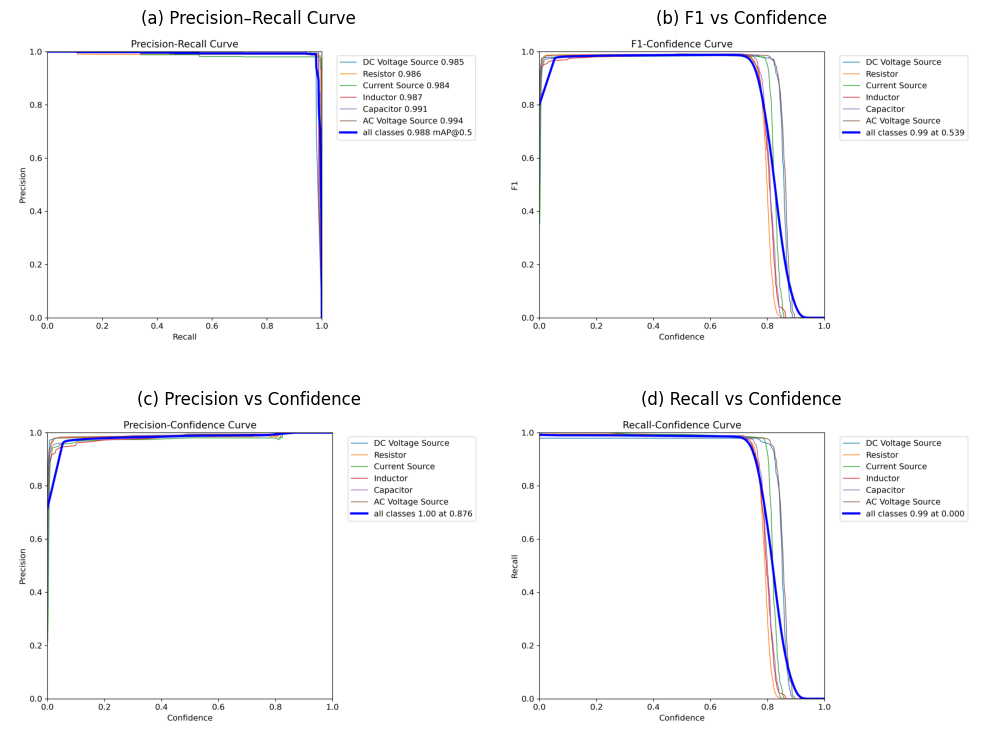

✅ Combined journal-style figure saved as YOLOv8_small_val_curves.svg


In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load YOLO's plots
pr = mpimg.imread("runs/detect/train3/BoxPR_curve.png")
f1 = mpimg.imread("runs/detect/train3/BoxF1_curve.png")
p  = mpimg.imread("runs/detect/train3/BoxP_curve.png")
r  = mpimg.imread("runs/detect/train3/BoxR_curve.png")

# Journal style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].imshow(pr); axs[0,0].axis("off"); axs[0,0].set_title("(a) Precision–Recall Curve")
axs[0,1].imshow(f1); axs[0,1].axis("off"); axs[0,1].set_title("(b) F1 vs Confidence")
axs[1,0].imshow(p);  axs[1,0].axis("off"); axs[1,0].set_title("(c) Precision vs Confidence")
axs[1,1].imshow(r);  axs[1,1].axis("off"); axs[1,1].set_title("(d) Recall vs Confidence")

plt.tight_layout()
plt.savefig("YOLOv8_small_val_curves.svg", format="svg", bbox_inches="tight")
plt.show()

print("✅ Combined journal-style figure saved as YOLOv8_small_val_curves.svg")
